In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [2]:
url='https://www.censtatd.gov.hk/api/get.php?id=310-31001&lang=en&full_series=1'

def read_json(url):
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}
    r=requests.get(url, headers=headers)
    if r.ok:
        data=r.json()
    return data

data=read_json(url)
hk_gdp=pd.DataFrame(list(filter(lambda i: (i['freq']=='Y') & (int(i['period'][:4])>1980) & (i['svDesc']=='HK$ million') 
                         & (i['sv']=='CUR'), data['dataSet'])))
hk_gdp=hk_gdp.set_index('period')
hk_gdp['gdp']=hk_gdp['figure']
hk_gdp.head()

,freq,sv,svDesc,figure,sd_value,gdp
period,,,,,,
1981,Y,CUR,HK$ million,173578,,173578
1982,Y,CUR,HK$ million,196005,,196005
1983,Y,CUR,HK$ million,217281,,217281
1984,Y,CUR,HK$ million,261992,,261992
1985,Y,CUR,HK$ million,278128,,278128


In [3]:
url='https://api.hkma.gov.hk/public/market-data-and-statistics/monthly-statistical-bulletin/money/supply-adjusted?pagesize=1500'
data=read_json(url)
# hk_m2=pd.DataFrame(list(filter(lambda i: '-12' in i['end_of_month'], data['result']['records'])))[['end_of_month', 'm2_total']]
hk_m2=pd.DataFrame(data['result']['records'])
hk_m2['M2']=hk_m2['m2_total']
hk_m2=hk_m2.set_index('end_of_month')
hk_m2.index=pd.to_datetime(hk_m2.index)

In [8]:
url='https://api.hkma.gov.hk/public/market-data-and-statistics/monthly-statistical-bulletin/ef-fc-resv-assets/fc-resv-assests?pagesize=1500'
data=read_json(url)
hk_exfund=pd.DataFrame(data['result']['records'])
hk_exfund=hk_exfund.set_index('end_of_month')
hk_exfund.index=pd.to_datetime(hk_exfund.index)
hk_exfund['reserve_in_hkd']=hk_exfund['fc_resv_assets_ef']*7.8

In [11]:
df_hk=pd.concat([hk_m2, hk_exfund], axis=1)
df_hk.columns

Index(['m1_hkd', 'm1_fc', 'm1_total', 'm2_hkd', 'm2_fc', 'm2_total', 'm3_hkd',
       'm3_fc', 'm3_total', 'M2', 'fc_resv_assets_ef', 'fc_resv_assets_lf',
       'fc_resv_assets_total', 'unsettle_fx_contracts_ef',
       'unsettle_fx_contracts_lf', 'unsettle_fx_contracts_total',
       'fc_assets_fx_contracts_ef', 'fc_assets_fx_contracts_lf',
       'fc_assets_fx_contracts_total', 'reserve_in_hkd'],
      dtype='object')

In [14]:
df_hk['m2_reserve']=df_hk['m2_total']/df_hk['reserve_in_hkd']
df_hk['m2_hkd_reserve']=df_hk['m2_hkd']/df_hk['reserve_in_hkd']
df_hk['m1_reserve']=df_hk['m1_total']/df_hk['reserve_in_hkd']
df_hk['m1_hkd_reserve']=df_hk['m1_hkd']/df_hk['reserve_in_hkd']

0.7982335081424234

C:\Users\tonyfong\AppData\Local\Temp\ipykernel_14764\3625961671.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_hk['m2_reserve'][-1]*0.89,
C:\Users\tonyfong\AppData\Local\Temp\ipykernel_14764\3625961671.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_hk['m2_reserve'][-1]*0.83,
C:\Users\tonyfong\AppData\Local\Temp\ipykernel_14764\3625961671.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_hk['m2_hkd_reserve'][-

Text(0.0, -0.03, 'Source: Hong Kong Monetary Authority')

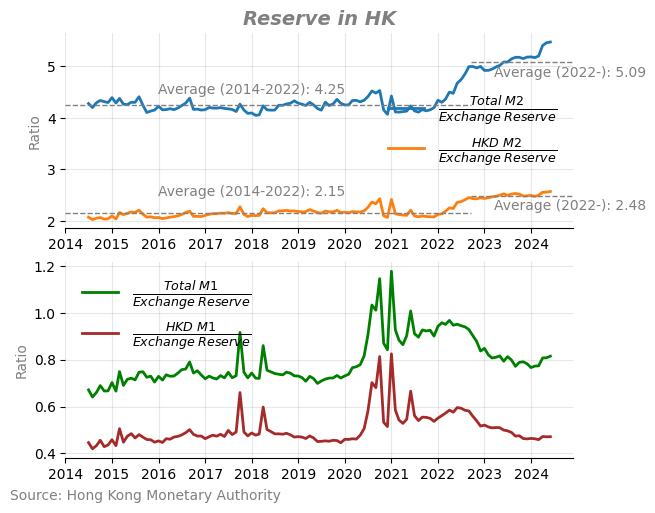

In [75]:
fig, axs = plt.subplots(2, 1, layout='constrained')
axs[0].plot(df_hk['m2_reserve'][-120:], label=r'$\frac{Total\ M2}{Exchange\ Reserve}$', linewidth=2)
axs[0].plot(df_hk['m2_hkd_reserve'][-120:], label=r'$\frac{HKD\ M2}{Exchange\ Reserve}$', linewidth=2)
# axs[0].set_xlabel('Year')
axs[0].set_title('Reserve in HK', fontsize=14,
            fontstyle='italic', fontweight='bold', color='grey')

xmin=(df_hk['m2_reserve'][-120:-24].index[-1]-
      df_hk['m2_reserve'][-120:-24].index[0])/(df_hk['m2_reserve'][-120:].index[-1]-
                                               df_hk['m2_reserve'][-120:].index[0])

# m2
axs[0].axhline(y=df_hk['m2_reserve'][-120:-23].mean(), xmax=xmin, color='grey', linestyle='--', linewidth=1)
axs[0].axhline(y=df_hk['m2_reserve'][-24:].mean(), xmin=xmin, 
               color='grey', linestyle='--', linewidth=1)

axs[0].text(
        df_hk.index[-1].year * 9.6,
        df_hk['m2_reserve'][-1]*0.89,
        f"Average (2022-): {str(round(df_hk['m2_reserve'][-24:].mean(),2))}",
        color='grey',
        # fontweight="bold",
        horizontalalignment="left",
        verticalalignment="center",
    )

axs[0].text(
        df_hk.index[-1].year * 8.3,
        df_hk['m2_reserve'][-1]*0.83,
        f"Average (2014-2022): {str(round(df_hk['m2_reserve'][-120:-23].mean(),2))}",
        color='grey',
        # fontweight="bold",
        horizontalalignment="left",
        verticalalignment="center",
    )

# m1
axs[0].axhline(y=df_hk['m2_hkd_reserve'][-120:-23].mean(), xmax=xmin, color='grey', linestyle='--', linewidth=1)
axs[0].axhline(y=df_hk['m2_hkd_reserve'][-24:].mean(), xmin=xmin, 
               color='grey', linestyle='--', linewidth=1)

axs[0].text(
        df_hk.index[-1].year * 9.6,
        df_hk['m2_hkd_reserve'][-1]*0.89,
        f"Average (2022-): {str(round(df_hk['m2_hkd_reserve'][-24:].mean(),2))}",
        color='grey',
        # fontweight="bold",
        horizontalalignment="left",
        verticalalignment="center",
    )

axs[0].text(
        df_hk.index[-1].year * 8.3,
        df_hk['m2_hkd_reserve'][-1],
        f"Average (2014-2022): {str(round(df_hk['m2_hkd_reserve'][-120:-23].mean(),2))}",
        color='grey',
        # fontweight="bold",
        horizontalalignment="left",
        verticalalignment="center",
    )



axs[1].plot(df_hk['m1_reserve'][-120:], label=r'$\frac{Total\ M1}{Exchange\ Reserve}$', color='green', linewidth=2)
axs[1].plot(df_hk['m1_hkd_reserve'][-120:], label=r'$\frac{HKD\ M1}{Exchange\ Reserve}$', color='brown', linewidth=2)
# axs[1].set_xlabel('Year')


# Hide the all but the bottom spines (axis lines)
for ax in axs:
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, prop={'size': 13, 'weight': 'bold'})
    # ax.legend(bbox_to_anchor=(0.67, -0.1), loc='upper center', frameon=False, ncol=5)
    ax.set_ylabel('Ratio',color='grey')

# fig.text(0.0, -0.03, 'Source: Monetary Authority of Macau, Macau Statistics and Census Service')
fig.text(0.0, -0.03, 'Source: Hong Kong Monetary Authority', color='grey')

<Axes: xlabel='end_of_month'>

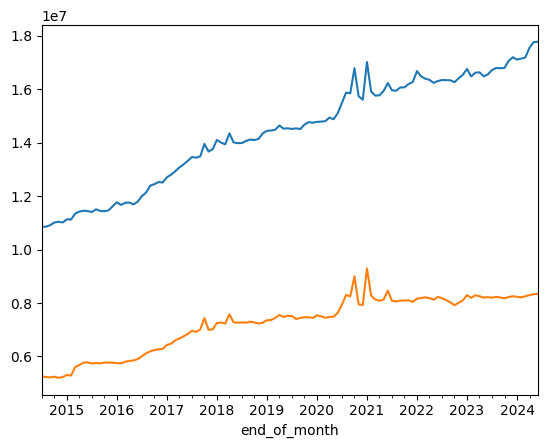

In [71]:
df_hk['m2_total'][-120:].plot()
df_hk['m2_hkd'][-120:].plot()

### Singapore

In [6]:
api_key='29de704f-b44b-494b-aa78-6d845add7dc0'
# headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36',
#            'keyid': api_key}
headers = {'keyid': api_key}
# url='https://eservices.mas.gov.sg/apimg-gw/server/monthly_statistical_bulletin/table_i_1a_money_supply_all_currencies/views/table_i_1a_money_supply_all_currencies?year=2024'
url='https://eservices.mas.gov.sg/apimg-gw/server/monthly_statistical_bulletin/table_i_1_money_supply_sgd/views/table_i_1_money_supply_sgd'
r=requests.get(url, headers=headers)
# r.json()
r

KeyboardInterrupt: 